# PSet 1 — Problem 5 (Python)

Two-period portfolio choice with risky and risk-free assets.

We use `hetmacro.quadrature.qnwnorm_mv` to build 2D Gaussian quadrature for $(\log y_2, \varepsilon_2)$.

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

here = Path.cwd()
repo_root = None
for p in [here] + list(here.parents):
    cand = p / 'Heterogeneity In Macroeconomics - Github'
    if cand.exists():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError('Could not locate hetmacro repo root')
sys.path.insert(0, str(repo_root))

from hetmacro import quadrature as hq
from hetmacro import optimize as hopt

np.set_printoptions(precision=4, suppress=True)

In [9]:
# Parameters
p = {
    'beta': 0.90,
    'sigma': 5.0,
    'gamma': 0.5,
    'r': 0.04,
    'mu': 0.06,
    'sigmae': 0.15,
    'sigmay': 0.20,
}

m_grid = np.linspace(0.1, 10.0, 1000)  # smaller default; can raise to 1000

## Quadrature for $(\log y_2, \varepsilon_2)$

We solve for two values of correlation $\rho$.

In [4]:
def build_quadrature(rho):
    mu = np.array([0.0, p['mu']])
    Sigma = np.array(
        [
            [p['sigmay'] ** 2, rho * p['sigmay'] * p['sigmae']],
            [rho * p['sigmay'] * p['sigmae'], p['sigmae'] ** 2],
        ]
    )
    nodes, weights = hq.qnwnorm_mv(np.array([7, 7]), mu, Sigma)
    logy2 = nodes[:, 0]
    eps2 = nodes[:, 1]
    y2 = np.exp(logy2)
    return y2, eps2, weights

## Objective and Euler errors (diagnostics)

Choice variables: $x\in[0,1]$ (save share), $x_s\in[0,1]$ (risky share of savings).

We solve a bounded 2D maximization for each $m$.

In [6]:
def value_for_m(xx, m, y2, eps2, w):
    x, xs = xx
    x = np.clip(x, 0.0, 1.0)
    xs = np.clip(xs, 0.0, 1.0)

    c1 = (1.0 - x) * m
    if c1 <= 0:
        return -1e18

    s = x * m
    # second period consumption
    c2 = y2 + (1.0 + p['r']) * s + eps2 * xs * s
    if np.any(c2 <= 0):
        return -1e18

    gamma = p['gamma']
    sigma = p['sigma']

    term1 = c1 ** (1.0 - gamma)
    Ec2 = np.dot(w, c2 ** (1.0 - sigma))
    term2 = (Ec2) ** ((1.0 - gamma) / (1.0 - sigma))
    V = (term1 + p['beta'] * term2) ** (1.0 / (1.0 - gamma))
    return float(V)


def solve_policies_for_rho(rho):
    y2, eps2, w = build_quadrature(rho)
    xx = np.zeros((m_grid.size, 2))
    for i, m in enumerate(m_grid):
        obj = lambda z: -value_for_m(z, m, y2, eps2, w)
        xx[i] = hopt.minimize_lbfgsb(
            obj,
            x0=np.array([0.3, 0.5]),
            bounds=[(0.0, 1.0), (0.0, 1.0)],
        )
    return xx

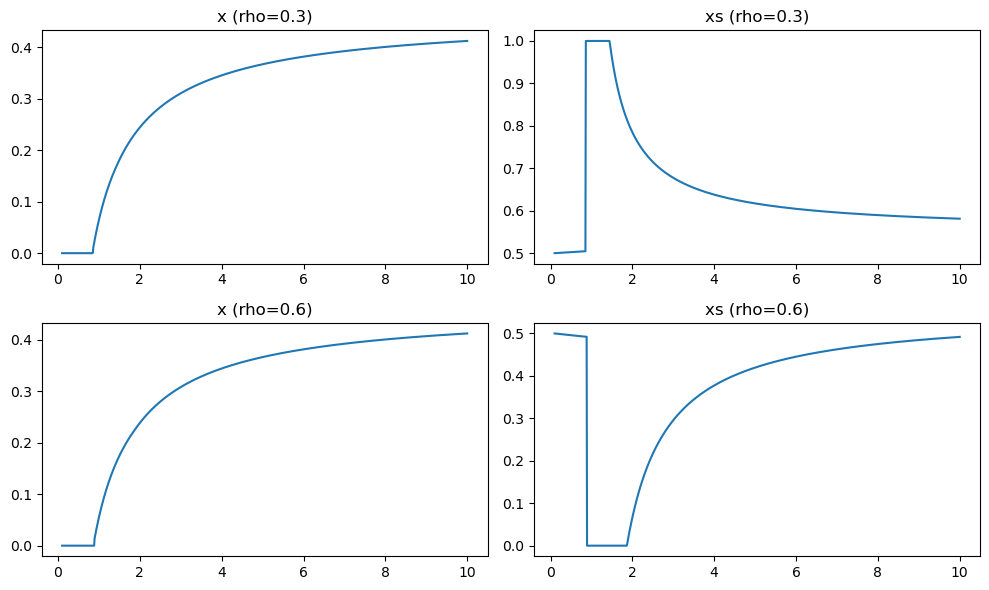

In [10]:
pol_03 = solve_policies_for_rho(0.3)
pol_06 = solve_policies_for_rho(0.6)

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(m_grid, pol_03[:, 0])
plt.title('x (rho=0.3)')

plt.subplot(2, 2, 2)
plt.plot(m_grid, pol_03[:, 1])
plt.title('xs (rho=0.3)')

plt.subplot(2, 2, 3)
plt.plot(m_grid, pol_06[:, 0])
plt.title('x (rho=0.6)')

plt.subplot(2, 2, 4)
plt.plot(m_grid, pol_06[:, 1])
plt.title('xs (rho=0.6)')

plt.tight_layout()
plt.show()